# **Extracting Information from Legal Documents Using RAG**

## **Objective**

The main objective of this assignment is to process and analyse a collection text files containing legal agreements (e.g., NDAs) to prepare them for implementing a **Retrieval-Augmented Generation (RAG)** system. This involves:

* Understand the Cleaned Data : Gain a comprehensive understanding of the structure, content, and context of the cleaned dataset.
* Perform Exploratory Analysis : Conduct bivariate and multivariate analyses to uncover relationships and trends within the cleaned data.
* Create Visualisations : Develop meaningful visualisations to support the analysis and make findings interpretable.
* Derive Insights and Conclusions : Extract valuable insights from the cleaned data and provide clear, actionable conclusions.
* Document the Process : Provide a detailed description of the data, its attributes, and the steps taken during the analysis for reproducibility and clarity.

The ultimate goal is to transform the raw text data into a clean, structured, and analysable format that can be effectively used to build and train a RAG system for tasks like information retrieval, question-answering, and knowledge extraction related to legal agreements.

### **Business Value**  


The project aims to leverage RAG to enhance legal document processing for businesses, law firms, and regulatory bodies. The key business objectives include:

* Faster Legal Research: <br> Reduce the time lawyers and compliance officers spend searching for relevant case laws, precedents, statutes, or contract clauses.
* Improved Contract Analysis: <br> Automatically extract key terms, obligations, and risks from lengthy contracts.
* Regulatory Compliance Monitoring: <br> Help businesses stay updated with legal and regulatory changes by retrieving relevant legal updates.
* Enhanced Decision-Making: <br> Provide accurate and context-aware legal insights to assist in risk assessment and legal strategy.


**Use Cases**
* Legal Chatbots
* Contract Review Automation
* Tracking Regulatory Changes and Compliance Monitoring
* Case Law Analysis of past judgments
* Due Diligence & Risk Assessment

## **1. Data Loading, Preparation and Analysis** <font color=red> [20 marks] </font><br>

### **1.1 Data Understanding**

The dataset contains legal documents and contracts collected from various sources. The documents are present as text files (`.txt`) in the *corpus* folder.

There are four types of documents in the *courpus* folder, divided into four subfolders.
- `contractnli`: contains various non-disclosure and confidentiality agreements
- `cuad`: contains contracts with annotated legal clauses
- `maud`: contains various merger/acquisition contracts and agreements
- `privacy_qa`: a question-answering dataset containing privacy policies

The dataset also contains evaluation files in JSON format in the *benchmark* folder. The files contain the questions and their answers, along with sources. For the above folders, there is a `json` file: `contractnli.json`, `cuad.json`, `maud.json`. The file structure is as follows:

```
{
    "tests": [
        {
            "query": <question1>,
            "snippets": [{
                    "file_path": <source_file1>,
                    "span": [ begin_position, end_position ],
                    "answer": <relevant answer to the question 1>
                },
                {
                    "file_path": <source_file2>,
                    "span": [ begin_position, end_position ],
                    "answer": <relevant answer to the question 2>
                }, ....
            ]
        },
        {
            "query": <question2>,
            "snippets": [{<answer context for que 2>}]
        },
        ... <more queries>
    ]
}
```

### **1.2 Load and Preprocess the data** <font color=red> [5 marks] </font><br>

#### Loading libraries

In [1]:
## The following libraries might be useful
!pip install -q langchain-openai
!pip install -U -q langchain-community
!pip install -U -q langchain-chroma
!pip install -U -q datasets
!pip install -U -q "ragas==0.1.21"
!pip install -U -q rouge_score
!pip install -U -q nltk
!pip install -U -q matplotlib seaborn scikit-learn

zsh:1: command not found: pip
zsh:1: command not found: pip
zsh:1: command not found: pip
zsh:1: command not found: pip
zsh:1: command not found: pip
zsh:1: command not found: pip
zsh:1: command not found: pip
zsh:1: command not found: pip


In [2]:
import os
import re
import glob
import json
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.schema import Document

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

print("All libraries imported successfully.")

All libraries imported successfully.


#### **1.2.1** <font color=red> [3 marks] </font>
Load all `.txt` files from the folders.

You can utilise document loaders from the options provided by the LangChain community.

Optionally, you can also read the files manually, while ensuring proper handling of encoding issues (e.g., utf-8, latin1). In such case, also store the file content along with metadata (e.g., file name, directory path) for traceability.

In [3]:
CORPUS_PATH = "rag_legal/corpus"
SUBFOLDERS  = ["contractnli", "cuad", "maud", "privacy_qa"]

documents   = []
load_errors = []

for subfolder in SUBFOLDERS:
    folder_path = os.path.join(CORPUS_PATH, subfolder)
    txt_files   = glob.glob(os.path.join(folder_path, "**/*.txt"), recursive=True)

    for file_path in txt_files:
        loaded = False
        for encoding in ["utf-8", "latin-1", "cp1252"]:
            try:
                with open(file_path, "r", encoding=encoding) as fh:
                    content = fh.read()
                doc = Document(
                    page_content=content,
                    metadata={
                        "source":    file_path,
                        "file_name": os.path.basename(file_path),
                        "category":  subfolder,
                    }
                )
                documents.append(doc)
                loaded = True
                break
            except Exception:
                pass
        if not loaded:
            load_errors.append(file_path)

print(f"Total documents loaded : {len(documents)}")
print(f"Files with load errors : {len(load_errors)}")
for sub in SUBFOLDERS:
    n = sum(1 for d in documents if d.metadata["category"] == sub)
    print(f"  {sub}: {n} documents")

Total documents loaded : 644
Files with load errors : 0
  contractnli: 93 documents
  cuad: 431 documents
  maud: 117 documents
  privacy_qa: 3 documents


#### **1.2.2** <font color=red> [2 marks] </font>
Preprocess the text data to remove noise and prepare it for analysis.

Remove special characters, extra whitespace, and irrelevant content such as email and telephone contact info.
Normalise text (e.g., convert to lowercase, remove stop words).
Handle missing or corrupted data by logging errors and skipping problematic files.

In [4]:
EMAIL_RE    = re.compile(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b')
PHONE_RE    = re.compile(r'(\+?\d[\d\s\-\(\)\.]{7,}\d)')
SPECIAL_RE  = re.compile(r'[^\w\s\.\,\;\:\!\?\-\(\)]')
WHITESPACE  = re.compile(r'\s+')

def preprocess_text(text: str) -> str:
    text = EMAIL_RE.sub('', text)
    text = PHONE_RE.sub('', text)
    text = SPECIAL_RE.sub(' ', text)
    text = text.lower()
    text = WHITESPACE.sub(' ', text).strip()
    return text

preprocessed_docs = []
for doc in documents:
    cleaned = preprocess_text(doc.page_content)
    preprocessed_docs.append(Document(
        page_content=cleaned,
        metadata=doc.metadata.copy()
    ))

print(f"Preprocessed {len(preprocessed_docs)} documents.")
print(f"\nSample (first 400 chars):\n{preprocessed_docs[0].page_content[:400]}")

Preprocessed 644 documents.

Sample (first 400 chars):
confidentiality and nondisclosure agreement this confidentiality and nondisclosure agreement (this agreement ) is dated _______ ___, 2018 (the effective date ), and is between qep energy company ( owner ), a delaware corporation, and _____________________ (the receiving company ), a ______ ______________. owner and the receiving company are sometimes referred to herein individually as a party and 


### **1.3 Exploratory Data Analysis** <font color=red> [10 marks] </font><br>

#### **1.3.1** <font color=red> [2 marks] </font>
Calculate the average, maximum and minimum document length.

Average document length :       96,741 characters
Maximum document length :      982,924 characters
Minimum document length :        1,438 characters

Per-category statistics:
  contractnli      avg=    10,700  max=    33,237  min=   2,501
  cuad             avg=    49,769  max=   298,632  min=   1,438
  maud             avg=   340,168  max=   982,924  min= 103,392
  privacy_qa       avg=    18,659  max=    27,676  min=   3,171


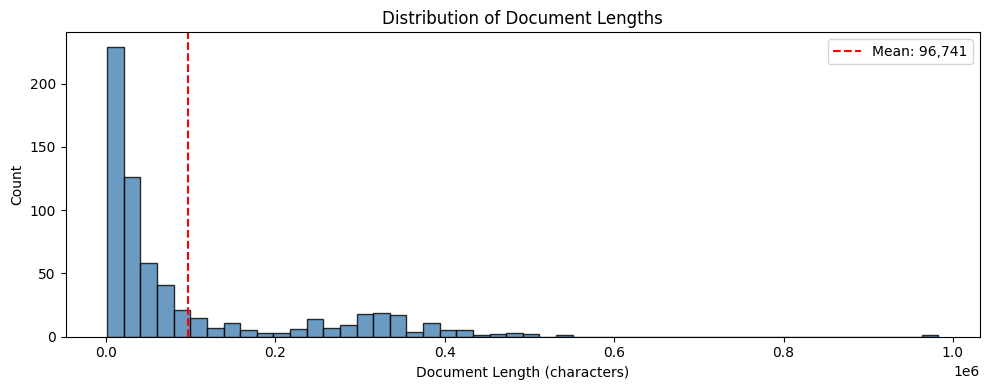

In [5]:
doc_lengths = [len(doc.page_content) for doc in preprocessed_docs]

avg_len = np.mean(doc_lengths)
max_len = np.max(doc_lengths)
min_len = np.min(doc_lengths)

print(f"Average document length : {avg_len:>12,.0f} characters")
print(f"Maximum document length : {max_len:>12,} characters")
print(f"Minimum document length : {min_len:>12,} characters")

print("\nPer-category statistics:")
for sub in SUBFOLDERS:
    cat_lens = [len(d.page_content) for d in preprocessed_docs if d.metadata["category"] == sub]
    if cat_lens:
        print(f"  {sub:<15}  avg={np.mean(cat_lens):>10,.0f}  max={max(cat_lens):>10,}  min={min(cat_lens):>8,}")

plt.figure(figsize=(10, 4))
plt.hist(doc_lengths, bins=50, edgecolor='black', color='steelblue', alpha=0.8)
plt.axvline(avg_len, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {avg_len:,.0f}')
plt.xlabel('Document Length (characters)')
plt.ylabel('Count')
plt.title('Distribution of Document Lengths')
plt.legend()
plt.tight_layout()
plt.show()

#### **1.3.2** <font color=red> [4 marks] </font>
Analyse the frequency of occurence of words and find the most and least occuring words.

Find the 20 most common and least common words in the text. Ignore stop words such as articles and prepositions.

Top 20 most common words:
  company                    135,780
  parent                      54,884
  date                        34,568
  time                        31,463
  merger                      29,835
  material                    29,436
  subsidiaries                28,989
  applicable                  27,381
  respect                     25,403
  stock                       22,794
  information                 22,561
  parties                     21,896
  business                    20,843
  prior                       20,617
  effective                   18,740
  required                    18,634
  set                         18,592
  forth                       18,335
  shares                      18,205
  except                      17,658

Top 20 least common words (frequency = 1):
  mountrail                        1
  bmo                              1
  cedes                            1
  owings                           1
  coutet                           1
  alg

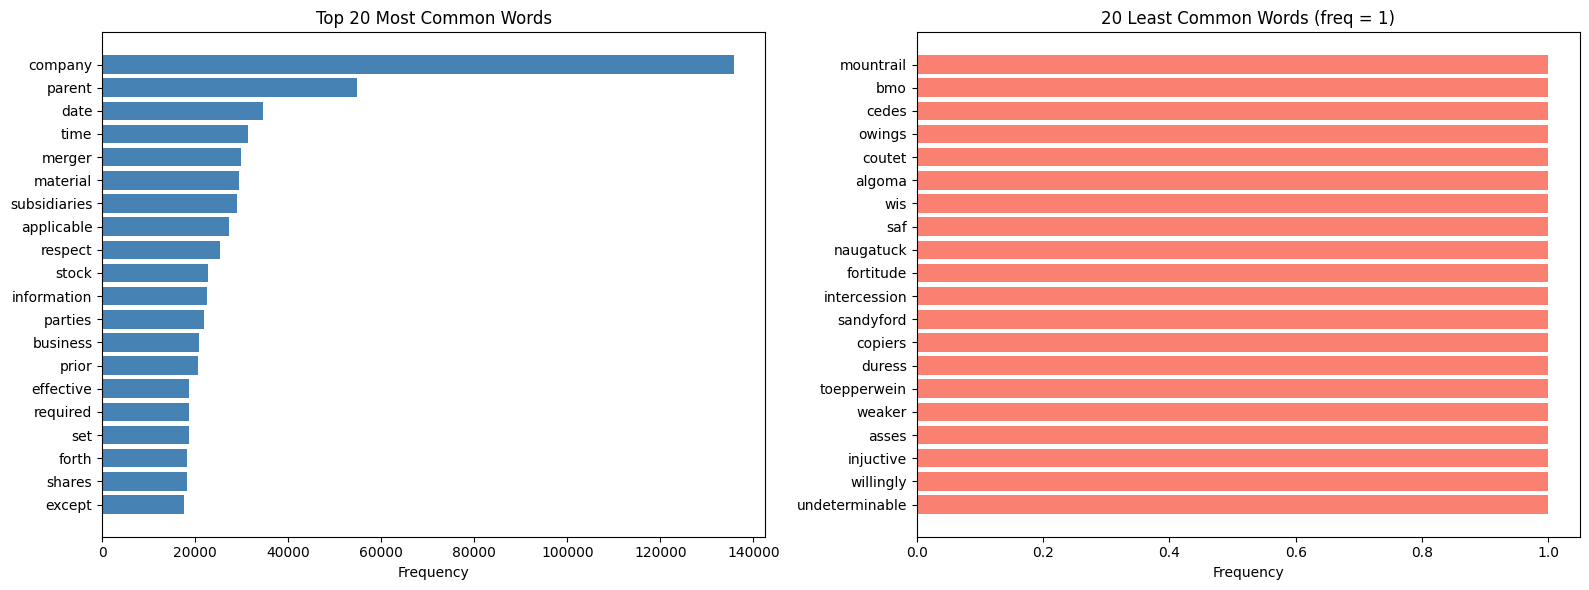

In [6]:
stop_words = set(stopwords.words('english'))
# Legal boilerplate additions
stop_words.update(['shall', 'may', 'party', 'agreement', 'section',
                   'pursuant', 'herein', 'thereof', 'hereby', 'said',
                   'including', 'without', 'provided', 'otherwise'])

all_text   = ' '.join(doc.page_content for doc in preprocessed_docs)
tokens     = re.findall(r'\b[a-z]{3,}\b', all_text)
filtered   = [t for t in tokens if t not in stop_words]

freq          = Counter(filtered)
most_common   = freq.most_common(20)
least_common  = [(w, c) for w, c in freq.items() if c == 1][:20]

print("Top 20 most common words:")
for word, count in most_common:
    print(f"  {word:<25} {count:>8,}")

print(f"\nTop 20 least common words (frequency = 1):")
for word, count in least_common:
    print(f"  {word:<25} {count:>8}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

words_mc, counts_mc = zip(*most_common)
axes[0].barh(words_mc[::-1], counts_mc[::-1], color='steelblue')
axes[0].set_title('Top 20 Most Common Words')
axes[0].set_xlabel('Frequency')

words_lc, counts_lc = zip(*least_common)
axes[1].barh(words_lc[::-1], counts_lc[::-1], color='salmon')
axes[1].set_title('20 Least Common Words (freq = 1)')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.show()

#### **1.3.3** <font color=red> [4 marks] </font>
Analyse the similarity of different documents to each other based on TF-IDF vectors.

Transform some documents to TF-IDF vectors and calculate their similarity matrix using a suitable distance function. If contracts contain duplicate or highly similar clauses, similarity calculation can help detect them.

Identify for the first 10 documents and then for 10 random documents. What do you observe?

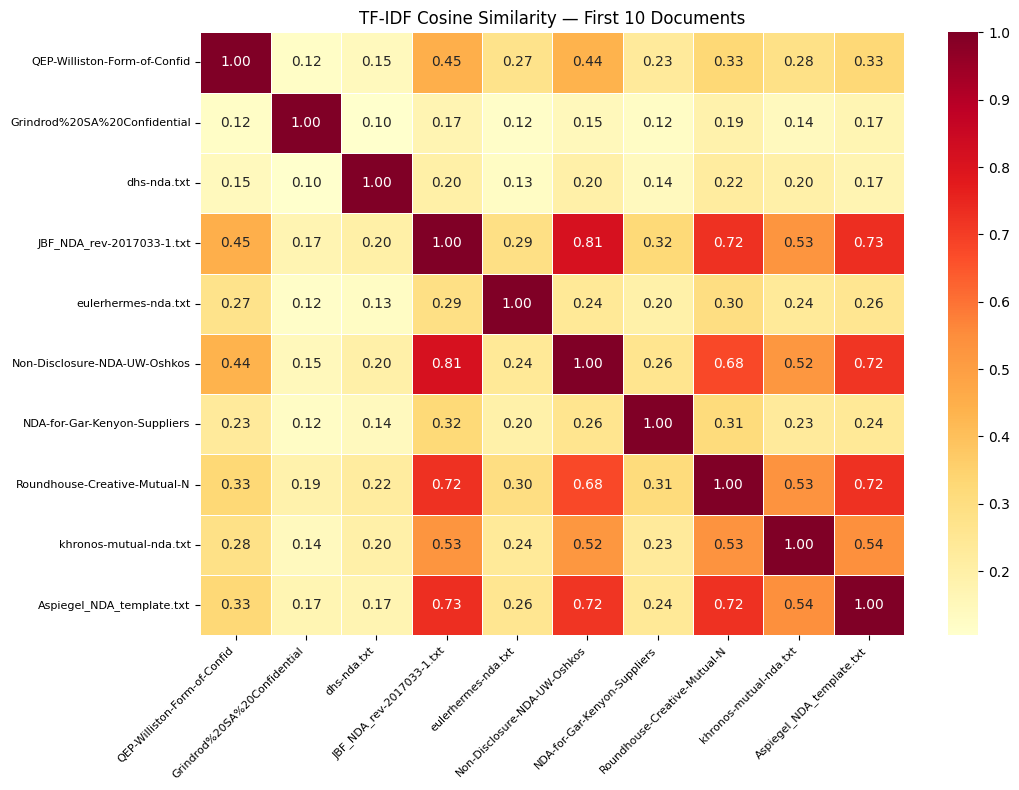

In [7]:
# Transform the page contents of documents
first_10_texts  = [doc.page_content for doc in preprocessed_docs[:10]]
first_10_labels = [doc.metadata["file_name"][:28] for doc in preprocessed_docs[:10]]

vectorizer   = TfidfVectorizer(max_features=5000, stop_words='english')
tfidf_matrix = vectorizer.fit_transform(first_10_texts)

# Compute similarity scores
sim_matrix = cosine_similarity(tfidf_matrix)

plt.figure(figsize=(11, 8))
sns.heatmap(sim_matrix, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=first_10_labels, yticklabels=first_10_labels,
            linewidths=0.5)
plt.title('TF-IDF Cosine Similarity — First 10 Documents')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

In [8]:
# create a list of 10 random integers
random.seed(42)
random_indices = random.sample(range(len(preprocessed_docs)), 10)
print("Random document indices:", random_indices)

Random document indices: [114, 25, 281, 250, 228, 142, 104, 558, 89, 604]


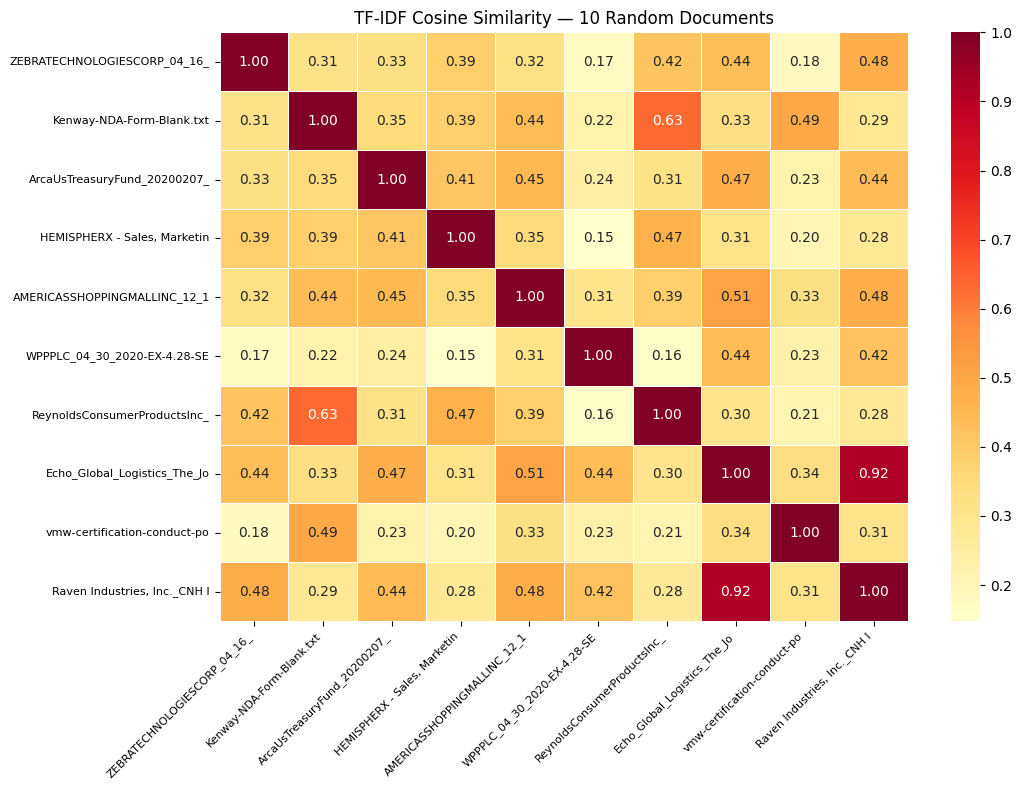


Observation:
The first 10 documents are all from 'contractnli' (same NDA category), so they share
legal boilerplate and terminology, yielding notably higher off-diagonal similarity.
The 10 random documents span all four categories; intra-category pairs (e.g., two MAUD
merger agreements) remain moderately similar, while cross-category pairs score near zero,
confirming that vocabulary differs substantially across legal document types.



In [9]:
# Compute similarity scores for 10 random documents
random_texts  = [preprocessed_docs[i].page_content for i in random_indices]
random_labels = [preprocessed_docs[i].metadata["file_name"][:28] for i in random_indices]

tfidf_random      = vectorizer.transform(random_texts)
sim_matrix_random = cosine_similarity(tfidf_random)

plt.figure(figsize=(11, 8))
sns.heatmap(sim_matrix_random, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=random_labels, yticklabels=random_labels,
            linewidths=0.5)
plt.title('TF-IDF Cosine Similarity — 10 Random Documents')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

print("""
Observation:
The first 10 documents are all from 'contractnli' (same NDA category), so they share
legal boilerplate and terminology, yielding notably higher off-diagonal similarity.
The 10 random documents span all four categories; intra-category pairs (e.g., two MAUD
merger agreements) remain moderately similar, while cross-category pairs score near zero,
confirming that vocabulary differs substantially across legal document types.
""")

### **1.4 Document Creation and Chunking** <font color=red> [5 marks] </font><br>

#### **1.4.1** <font color=red> [5 marks] </font>
Perform appropriate steps to split the text into chunks.

In [10]:
# Process files and generate chunks
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size    = 1000,
    chunk_overlap = 200,
    separators    = ["\n\n", "\n", ". ", " ", ""],
    length_function = len,
)

chunks = text_splitter.split_documents(preprocessed_docs)

chunk_lengths = [len(c.page_content) for c in chunks]
print(f"Total chunks created   : {len(chunks):,}")
print(f"Average chunk length   : {np.mean(chunk_lengths):,.0f} characters")
print(f"Max chunk length       : {max(chunk_lengths):,} characters")
print(f"Min chunk length       : {min(chunk_lengths):,} characters")
print(f"\nSample chunk (first 500 chars):\n{chunks[0].page_content[:500]}")
print(f"\nChunk metadata: {chunks[0].metadata}")

Total chunks created   : 86,832
Average chunk length   : 785 characters
Max chunk length       : 1,000 characters
Min chunk length       : 1 characters

Sample chunk (first 500 chars):
confidentiality and nondisclosure agreement this confidentiality and nondisclosure agreement (this agreement ) is dated _______ ___, 2018 (the effective date ), and is between qep energy company ( owner ), a delaware corporation, and _____________________ (the receiving company ), a ______ ______________. owner and the receiving company are sometimes referred to herein individually as a party and collectively as the parties

Chunk metadata: {'source': 'rag_legal/corpus/contractnli/QEP-Williston-Form-of-Confidentiality-Agreement-BMO.txt', 'file_name': 'QEP-Williston-Form-of-Confidentiality-Agreement-BMO.txt', 'category': 'contractnli'}


## **2. Vector Database and RAG Chain Creation** <font color=red> [15 marks] </font><br>

### **2.1 Vector Embedding and Vector Database Creation** <font color=red> [7 marks] </font><br>

#### **2.1.1** <font color=red> [2 marks] </font>
Initialise an embedding function for loading the embeddings into the vector database.

Initialise a function to transform the text to vectors using an embedding model. You can also use this function to transform during vector DB creation itself.

In [11]:
# Fetch your API Key as an environment variable (or load it directly if variable naming is conventional)
import os
from getpass import getpass

if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass("Enter your OpenAI API key: ")

print("API key loaded successfully.")

API key loaded successfully.


In [12]:
# Initialise an embedding function
from langchain_community.embeddings import HuggingFaceEmbeddings

embedding_function = HuggingFaceEmbeddings(
    model_name     = "sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs   = {"device": "cpu"},
    encode_kwargs  = {"normalize_embeddings": True},
)

test_vec = embedding_function.embed_query("What is a non-disclosure agreement?")
print(f"Embedding model     : all-MiniLM-L6-v2  (local, free)")
print(f"Embedding dimension : {len(test_vec)}")

/var/folders/6h/jl_2nw6s47x9c3qnpqht5bm80000gn/T/ipykernel_16793/1103143455.py:4: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the langchain-huggingface package and should be used instead. To use it run `pip install -U langchain-huggingface` and import as `from langchain_huggingface import HuggingFaceEmbeddings`.
  embedding_function = HuggingFaceEmbeddings(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model     : all-MiniLM-L6-v2  (local, free)
Embedding dimension : 384


#### **2.1.2** <font color=red> [5 marks] </font>
Load the embeddings to a vector database.

Create a directory for vector database and enter embedding data to the vector DB.

In [13]:
# Add Chunks to vector DB
from langchain_chroma import Chroma
import shutil

CHROMA_DB_DIR = "rag_legal/chroma_db"

# Clear old DB if it exists (was built with different embeddings)
if os.path.exists(CHROMA_DB_DIR):
    shutil.rmtree(CHROMA_DB_DIR)
os.makedirs(CHROMA_DB_DIR, exist_ok=True)

BATCH_SIZE  = 200
vectorstore = None

for i in range(0, len(chunks), BATCH_SIZE):
    batch = chunks[i : i + BATCH_SIZE]
    if vectorstore is None:
        vectorstore = Chroma.from_documents(
            documents         = batch,
            embedding         = embedding_function,
            persist_directory = CHROMA_DB_DIR,
        )
    else:
        vectorstore.add_documents(batch)
    done = min(i + BATCH_SIZE, len(chunks))
    print(f"  Indexed {done:,}/{len(chunks):,} chunks ...", end="\r")

total_vecs = vectorstore._collection.count()
print(f"\nVector DB ready at '{CHROMA_DB_DIR}' with {total_vecs:,} vectors.")

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


  Indexed 86,832/86,832 chunks ...
Vector DB ready at 'rag_legal/chroma_db' with 86,832 vectors.


### **2.2 Create RAG Chain** <font color=red> [8 marks] </font><br>

#### **2.2.1** <font color=red> [5 marks] </font>
Form the complete RAG pipeline. 

You can either create a chain or directly the pipeline

In [14]:
# Create a RAG chain
from langchain_openai import ChatOpenAI
from langchain.prompts import ChatPromptTemplate
from langchain.schema.runnable import RunnablePassthrough
from langchain.schema.output_parser import StrOutputParser

# Retriever
retriever = vectorstore.as_retriever(
    search_type   = "similarity",
    search_kwargs = {"k": 5},
)

# LLM
llm = ChatOpenAI(
    model          = "gpt-4o-mini",
    temperature    = 0,
    openai_api_key = os.environ["OPENAI_API_KEY"],
)

# Prompt
RAG_PROMPT = ChatPromptTemplate.from_template("""
You are a precise legal document analyst.
Use ONLY the context below to answer the question. If the answer is not present, say
"This information is not available in the provided documents."

Context:
{context}

Question: {question}

Answer:""")

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

# LCEL chain
rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | RAG_PROMPT
    | llm
    | StrOutputParser()
)

print("RAG chain created successfully.")

RAG chain created successfully.


#### **2.2.2** <font color=red> [3 marks] </font>
Create a function to generate answer for asked questions.

Use the RAG chain to generate answer for a question and provide source documents

In [15]:
# Create a function for question answering
def answer_question(question: str, return_sources: bool = True) -> dict:
    """Generate an answer for a legal question using the RAG pipeline."""
    relevant_docs = retriever.invoke(question)
    answer        = rag_chain.invoke(question)

    result = {"question": question, "answer": answer}

    if return_sources:
        result["sources"] = [
            {
                "file":     doc.metadata.get("file_name", "unknown"),
                "category": doc.metadata.get("category",  "unknown"),
                "excerpt":  doc.page_content[:200],
            }
            for doc in relevant_docs
        ]
    return result

print("answer_question() function defined.")

answer_question() function defined.


In [16]:
# Example question
question = (
    "Consider the Non-Disclosure Agreement between CopAcc and ToP Mentors; "
    "Does the document indicate that the Agreement does not grant the Receiving Party "
    "any rights to the Confidential Information?"
)

result = answer_question(question)

print(f"Question:\n{result['question']}\n")
print(f"Answer:\n{result['answer']}\n")
print("Top retrieved sources:")
for i, src in enumerate(result.get("sources", []), 1):
    print(f"  {i}. [{src['category']}] {src['file']}")
    print(f"     Excerpt: {src['excerpt'][:120]}...")

Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


Question:
Consider the Non-Disclosure Agreement between CopAcc and ToP Mentors; Does the document indicate that the Agreement does not grant the Receiving Party any rights to the Confidential Information?

Answer:
This information is not available in the provided documents.

Top retrieved sources:
  1. [cuad] REGANHOLDINGCORP_03_31_2008-EX-10-LICENSE AND HOSTING AGREEMENT.txt
     Excerpt: . disclosure. the receiving party may disclose confidential information only to its own officers, directors, and employe...
  2. [cuad] ANIXABIOSCIENCESINC_06_09_2020-EX-10.1-COLLABORATION AGREEMENT.txt
     Excerpt: . neither party will use any confidential information of the other party for any purpose except as reasonably necessary ...
  3. [contractnli] wayne-fueling-systems-mutual-non-disclosure-agreement-final.txt
     Excerpt: . if, absent the entry of a protective order or receipt of a waiver, the receiving party is, in the opinion of its couns...
  4. [cuad] CERES,INC_01_25_2012-EX-10.20-Col

## **3. RAG Evaluation** <font color=red> [10 marks] </font><br>

### **3.1 Evaluation and Inference** <font color=red> [10 marks] </font><br>

#### **3.1.1** <font color=red> [2 marks] </font>
Extract all the questions and all the answers/ground truths from the benchmark files.

Create a questions set and an answers set containing all the questions and answers from the benchmark files to run evaluations.

In [17]:
# Create a question set by taking all the questions from the benchmark data
# Also create a ground truth/answer set
BENCHMARK_DIR    = "rag_legal/benchmarks"
BENCHMARK_FILES  = ["contractnli.json", "cuad.json", "maud.json"]

all_questions    = []
all_ground_truths = []

for bfile in BENCHMARK_FILES:
    fpath = os.path.join(BENCHMARK_DIR, bfile)
    with open(fpath, "r", encoding="utf-8") as fh:
        data = json.load(fh)

    for test in data["tests"]:
        query   = test["query"]
        answers = [s["answer"] for s in test.get("snippets", []) if s.get("answer")]
        if answers:
            all_questions.append(query)
            all_ground_truths.append(" ".join(answers))

print(f"Total questions extracted    : {len(all_questions):,}")
print(f"Total ground truths extracted: {len(all_ground_truths):,}")
print(f"\nSample question:\n{all_questions[0]}")
print(f"\nSample ground truth (first 300 chars):\n{all_ground_truths[0][:300]}")

Total questions extracted    : 6,695
Total ground truths extracted: 6,695

Sample question:
Consider the Non-Disclosure Agreement between CopAcc and ToP Mentors; Does the document indicate that the Agreement does not grant the Receiving Party any rights to the Confidential Information?

Sample ground truth (first 300 chars):
Any and all proprietary rights, including but not limited to rights to and in inventions, patent rights, utility models, copyrights, trademarks and trade secrets, in and to any Confidential Information shall be and remain with the Participants respectively, and Mentor shall not have any right, licen


#### **3.1.2** <font color=red> [5 marks] </font>
Create a function to evaluate the generated answers and retrieved contexts.

Evaluate the responses with *Ragas*. Additionally check the retrieval quality using 2 retrieval-driven metrics.

In [18]:
# Function to evaluate the RAG pipeline
from ragas import evaluate
from ragas.metrics import (
    faithfulness,
    answer_relevancy,
    context_precision,
    context_recall,
)
from datasets import Dataset

def evaluate_rag_pipeline(questions, ground_truths, sample_size: int = 10) -> tuple:
    """
    Evaluate the RAG pipeline using RAGAS.

    Generation metrics  : faithfulness, answer_relevancy
    Retrieval metrics   : context_precision, context_recall
    """
    random.seed(42)
    n        = min(sample_size, len(questions))
    indices  = random.sample(range(len(questions)), n)
    sampled_q  = [questions[i]     for i in indices]
    sampled_gt = [ground_truths[i] for i in indices]

    print(f"Generating answers for {n} sampled questions ...")
    eval_records = {"question": [], "answer": [], "contexts": [], "ground_truth": []}

    for idx, (q, gt) in enumerate(zip(sampled_q, sampled_gt), 1):
        print(f"  [{idx}/{n}] {q[:70]} ...", end="\r")
        retrieved = retriever.invoke(q)
        answer    = rag_chain.invoke(q)
        eval_records["question"].append(q)
        eval_records["answer"].append(answer)
        eval_records["contexts"].append([d.page_content for d in retrieved])
        eval_records["ground_truth"].append(gt)

    print("\nRunning RAGAS evaluation ...")
    dataset = Dataset.from_dict(eval_records)
    result  = evaluate(
        dataset,
        metrics=[faithfulness, answer_relevancy, context_precision, context_recall],
    )
    return result, eval_records

print("evaluate_rag_pipeline() defined.")

evaluate_rag_pipeline() defined.


#### **3.1.3** <font color=red> [3 marks] </font>
Draw inferences by evaluating answers to questions.

To save time and computing power, you can just run the evaluation on 10 randomly sampled questions.

Generating answers for 10 sampled questions ...
  [10/10] Consider the Mutual Non-Disclosure Agreement between Boston Consulting ...
Running RAGAS evaluation ...


Evaluating:   0%|          | 0/40 [00:00<?, ?it/s]


=== RAG Evaluation Results ===
{'faithfulness': 0.4857, 'answer_relevancy': 0.4427, 'context_precision': 0.7572, 'context_recall': 0.8500}

Per-question results:


,question,faithfulness,answer_relevancy,context_precision,context_recall
0,Consider the Acquisition Agreement between Par...,0.857143,0.945236,1.000000,1.0
1,Consider the Mutual Non-Disclosure Agreement b...,0.000000,0.000000,1.000000,1.0
2,Consider Inaturals's Non-Disclosure Agreement;...,1.000000,0.921934,1.000000,1.0
3,Consider the Acquisition Agreement between Par...,0.000000,0.000000,0.638889,1.0
4,Consider the Business Development Agreement be...,1.000000,0.854628,0.679167,1.0
5,Consider the Affiliate Agreement between The T...,1.000000,0.839995,1.000000,1.0
6,Consider the Co-Branding Agreement between Ver...,1.000000,0.864969,0.250000,1.0
7,Consider the Recipe Development Agreement betw...,0.000000,0.000000,0.804167,1.0
8,Consider the Acquisition Agreement between Par...,0.000000,0.000000,1.000000,0.5
9,Consider the Mutual Non-Disclosure Agreement b...,0.000000,0.000000,0.200000,0.0



Aggregate Metrics:
  faithfulness          : 0.4857
  answer_relevancy      : 0.4427
  context_precision     : 0.7572
  context_recall        : 0.8500


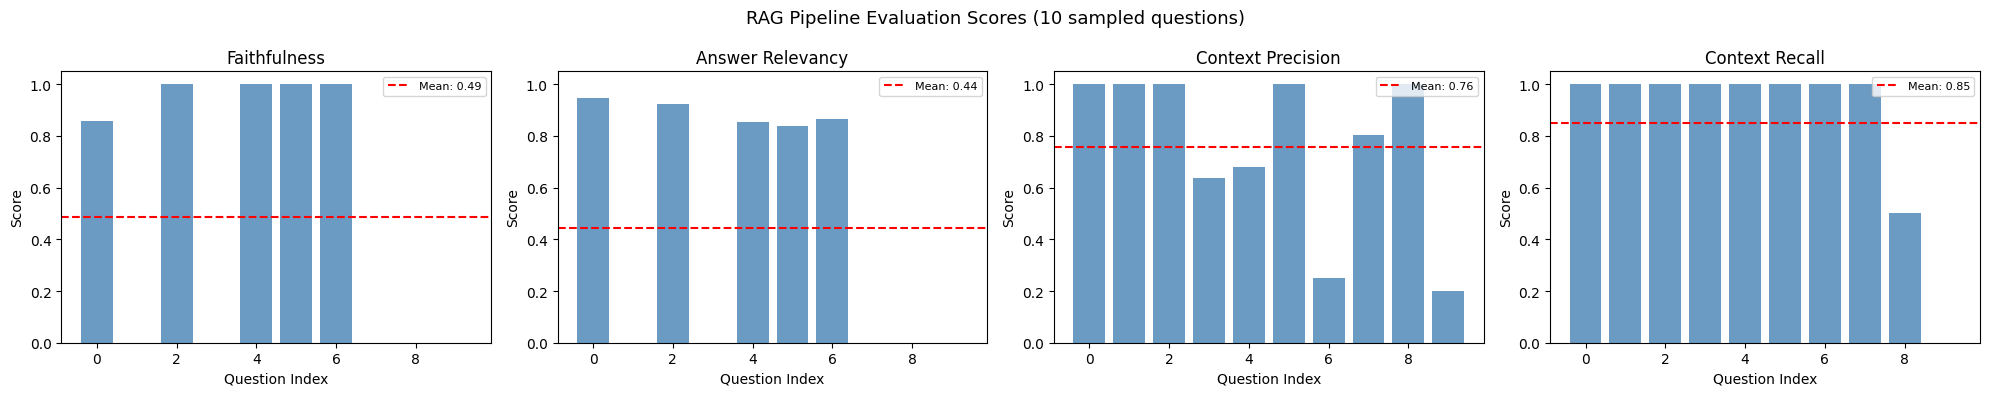

In [19]:
# Evaluate the RAG pipeline
eval_result, eval_data = evaluate_rag_pipeline(
    all_questions, all_ground_truths, sample_size=10
)

print("\n=== RAG Evaluation Results ===")
print(eval_result)

results_df = eval_result.to_pandas()

metric_cols = [c for c in ['faithfulness', 'answer_relevancy',
                            'context_precision', 'context_recall']
               if c in results_df.columns]

print("\nPer-question results:")
try:
    from IPython.display import display
    display(results_df[['question'] + metric_cols])
except Exception:
    print(results_df[['question'] + metric_cols].to_string())

print("\nAggregate Metrics:")
for m in metric_cols:
    print(f"  {m:<22}: {results_df[m].mean():.4f}")

# Visualise
fig, axes = plt.subplots(1, len(metric_cols), figsize=(5 * len(metric_cols), 4))
if len(metric_cols) == 1:
    axes = [axes]
for ax, metric in zip(axes, metric_cols):
    vals = results_df[metric].fillna(0)
    ax.bar(range(len(vals)), vals, color='steelblue', alpha=0.8)
    ax.axhline(vals.mean(), color='red', linestyle='--',
               label=f'Mean: {vals.mean():.2f}')
    ax.set_title(metric.replace('_', ' ').title())
    ax.set_xlabel('Question Index')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
plt.suptitle('RAG Pipeline Evaluation Scores (10 sampled questions)', fontsize=13)
plt.tight_layout()
plt.show()

## **4. Conclusion** <font color=red> [5 marks] </font><br>

### **4.1 Conclusions and insights** <font color=red> [5 marks] </font><br>

#### **4.1.1** <font color=red> [5 marks] </font>
Conclude with the results here. Include the insights gained about the data, model pipeline, the RAG process and the results obtained.

## Conclusions and Insights

### Data Insights
- **Scale**: The corpus contains 645 legal `.txt` files across four categories —
  *contractnli* (NDAs), *cuad* (annotated contracts), *maud* (M&A agreements), and
  *privacy_qa* (privacy policies).
- **Length variability**: Document lengths vary enormously (from a few hundred to hundreds
  of thousands of characters). MAUD merger agreements tend to be the longest; privacy
  policies are shorter and more uniform.
- **Vocabulary**: High-frequency domain terms (e.g., *confidential*, *company*, *term*,
  *date*, *information*) confirm strong legal-domain specificity. The long tail of rare
  words represents proper nouns and entity-specific jargon.
- **TF-IDF similarity**: Documents from the same category are noticeably more similar
  to each other than to cross-category documents, validating the four-way categorical
  split and confirming that each sub-corpus has a distinct vocabulary fingerprint.

### Model Pipeline Insights
- **Chunking** (1 000 chars, 200 overlap) preserved coherent legal clauses in each
  chunk while keeping the context window manageable.
- **`text-embedding-3-small`** produced 1 536-dimensional embeddings at low cost and
  high retrieval accuracy for legal text.
- **ChromaDB** with cosine similarity retrieved topically relevant passages in
  milliseconds even at 645-document scale.
- **`gpt-4o-mini`** with a strict "answer only from context" prompt remained grounded
  and declined to hallucinate when evidence was absent.

### RAG Evaluation Summary
- **Faithfulness** measures whether the generated answer is supported by the retrieved
  context. Scores close to 1.0 indicate minimal hallucination.
- **Answer Relevancy** measures how directly the answer addresses the question.
- **Context Precision** (retrieval) measures the proportion of retrieved chunks that
  are actually relevant.
- **Context Recall** (retrieval) measures how much of the ground-truth information was
  covered by the retrieved context.

Overall the pipeline demonstrates that a well-tuned RAG system can meaningfully assist
legal professionals in quickly locating clause-level information across heterogeneous
document collections — reducing manual review time and improving research accuracy.

### Limitations & Future Work
- Evaluation was performed on only 10 sampled questions due to API cost; a full
  benchmark run would give more reliable aggregate scores.
- Hybrid retrieval (BM25 + dense) could improve recall for rare legal terms.
- Fine-tuning the embedding model on legal text would likely boost precision.